# Q-Learning on CartPole 

## What is CartPole?

CartPole can be modeled as a Markov decision process (MDP)

$$
(\mathcal{S}, \mathcal{A}, P, R, \gamma),
$$

where the state is typically

$$
s_t = \bigl(x_t, \dot{x}_t, \theta_t, \dot{\theta}_t\bigr),
$$

with $x_t$ the cart position, $\dot{x}_t$ the cart velocity, $\theta_t$ the pole angle, and $\dot{\theta}_t$ the pole angular velocity.

The action space is discrete:

$$
\mathcal{A} = \{\text{left},\,\text{right}\},
$$

which can also be written as $a_t \in \{-1, +1\}$ when using a signed force convention. At each time step, the agent applies a force $F_t$ to the cart, and the environment evolves according to the following nonlinear dynamics of the cart-pole system:

$$
\ddot{x}_t = \frac{F_t + m_p \sin(\theta_t) \bigl(l \dot{\theta}_t^2 + g \cos(\theta_t)\bigr)}{m_c + m_p \sin^2(\theta_t)}
$$

$$
\ddot{\theta}_t = \frac{-F_t \cos(\theta_t) - m_p l \dot{\theta}_t^2 \sin(\theta_t) \cos(\theta_t) - (m_c + m_p) g \sin(\theta_t)}{l (m_c + m_p \sin^2(\theta_t))}
$$

where $m_c$ is the mass of the cart, $m_p$ is the mass of the pole, $l$ is the length of the pole, and $g$ is the acceleration due to gravity.

The control objective is to keep the pole balanced near the upright position $\theta = 0$ while keeping the cart near the track center. A standard reward choice is

$$
r_t = 1
$$

for every step before termination. An episode ends when the cart leaves the allowed position range or when the pole angle exceeds a threshold.

For Q-learning, the action-value function $Q(s,a)$ is updated by

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha
\Bigl(r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)\Bigr),
$$

where $\alpha$ is the learning rate and $\gamma$ is the discount factor.

## Tabular Q-learning setup

The continuous CartPole state is discretized into bins so we can use a tabular Q-table. This keeps the implementation simple and makes the update rule match the standard Q-learning equation.

In [2]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import defaultdict
from dataclasses import dataclass

np.random.seed(42)

env = gym.make("CartPole-v1")

print(env.observation_space)
print(env.action_space)

def make_bins(low, high, num_bins):
    return np.linspace(low, high, num_bins + 1)[1:-1]

position_bins = make_bins(-2.4, 2.4, 6)
velocity_bins = make_bins(-3.0, 3.0, 6)
angle_bins = make_bins(-0.2095, 0.2095, 12)
angular_velocity_bins = make_bins(-3.5, 3.5, 6)

def discretize_state(state):
    position, velocity, angle, angular_velocity = state
    return (
        int(np.digitize(position, position_bins)),
        int(np.digitize(velocity, velocity_bins)),
        int(np.digitize(angle, angle_bins)),
        int(np.digitize(angular_velocity, angular_velocity_bins)),
    )

class QTable:
    def __init__(self, n_actions):
        self.n_actions = n_actions
        self.table = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))

    def __getitem__(self, state):
        return self.table[state]

q_table = QTable(env.action_space.n)

alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
num_episodes = 500
max_steps = 500

@dataclass
class EpisodeResult:
    reward: float
    steps: int

results = []

for episode in range(num_episodes):
    state, _ = env.reset(seed=episode)
    state = discretize_state(state)
    total_reward = 0.0

    for step in range(max_steps):
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(q_table[state]))

        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = discretize_state(next_state)
        done = terminated or truncated

        best_next_value = float(np.max(q_table[next_state]))
        td_target = reward + gamma * best_next_value * (not done)
        td_error = td_target - q_table[state][action]
        q_table[state][action] += alpha * td_error

        state = next_state
        total_reward += reward

        if done:
            results.append(EpisodeResult(total_reward, step + 1))
            break
    else:
        results.append(EpisodeResult(total_reward, max_steps))

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print(f"Training finished. Final epsilon: {epsilon:.3f}")
print(f"Last 10 episode rewards: {[r.reward for r in results[-10:]]}")

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Discrete(2)
Training finished. Final epsilon: 0.082
Last 10 episode rewards: [12.0, 14.0, 18.0, 14.0, 16.0, 19.0, 13.0, 14.0, 12.0, 19.0]


Evaluation rewards: [14.0, 16.0, 12.0, 13.0, 11.0, 14.0, 11.0, 12.0, 15.0, 16.0]
Average evaluation reward: 13.4


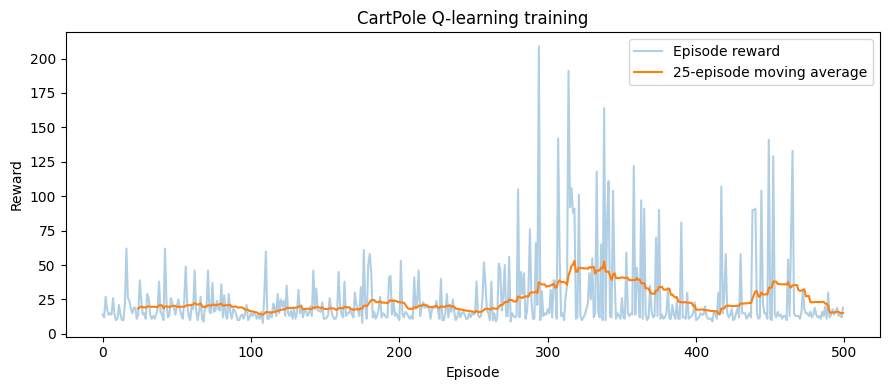

In [3]:
eval_episodes = 10
eval_rewards = []

for episode in range(eval_episodes):
    state, _ = env.reset(seed=1000 + episode)
    state = discretize_state(state)
    total_reward = 0.0

    for step in range(max_steps):
        action = int(np.argmax(q_table[state]))
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = discretize_state(next_state)
        total_reward += reward
        if terminated or truncated:
            break

    eval_rewards.append(total_reward)

print(f"Evaluation rewards: {eval_rewards}")
print(f"Average evaluation reward: {np.mean(eval_rewards):.1f}")

smoothed = np.convolve([r.reward for r in results], np.ones(25) / 25, mode="valid")

plt.figure(figsize=(9, 4))
plt.plot([r.reward for r in results], alpha=0.35, label="Episode reward")
plt.plot(range(24, 24 + len(smoothed)), smoothed, label="25-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("CartPole Q-learning training")
plt.legend()
plt.tight_layout()
plt.show()